# Libraries

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
from dateutil.relativedelta import relativedelta

In [34]:
import numpy as np
from scipy.optimize import minimize
from scipy.special import erfi
import warnings
from datetime import datetime

def erfid(x, y):
    """Calculates difference between imaginary error functions (erfi(x/√2) - erfi(y/√2))"""
    return erfi(x/np.sqrt(2)) - erfi(y/np.sqrt(2))

def mu(d, u, c, f, sigma, theta, l):
    """Computes strategy return given bands d (lower) and u (upper)"""
    term1 = np.log(1 + f*(np.exp(sigma*(u - d - c)) - 1)) / erfid(u, d)
    term2 = np.log(1 + f*(np.exp(sigma*(l - d - c)) - 1)) / erfid(d, l)
    return (2/(theta*np.pi)) * (term1 + term2)

def maximize_mu(c_vals, l, sigma, theta, f):
    """Main optimization function (sequential version)"""
    n = len(c_vals)
    d_vals = np.zeros(n)
    u_vals = np.zeros(n)
    
    # Initial guess [d, u]
    x0 = np.array([-0.5, 0.5])
    
    for i, c in enumerate(c_vals):
        # Bounds for current cost value
        bounds = [(l + 0.01, 0.6), (l + c, 3)]
        
        # Constraints for current cost
        constraints = [
            {'type': 'ineq', 'fun': lambda x: x[1] - x[0] - c},  # u-d > c
            {'type': 'ineq', 'fun': lambda x: x[0] - l},         # d > l
            {'type': 'ineq', 'fun': lambda x: x[1] - x[0]}       # u > d
        ]
        
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                
                res = minimize(
                    fun=lambda x: -mu(x[0], x[1], c, f, sigma, theta, l),
                    x0=x0,
                    bounds=bounds,
                    constraints=constraints,
                    method='SLSQP',
                    options={'maxiter': 500, 'ftol': 1e-8}
                )
                
                if res.success:
                    d_vals[i], u_vals[i] = res.x
                else:
                    d_vals[i], u_vals[i] = np.nan, np.nan
                    
        except:
            d_vals[i], u_vals[i] = np.nan, np.nan
    
    return d_vals, u_vals

def plot_BANDSvsCOST(c_vals, d_vals, u_vals, flag, c_bar=None, d_star=None, u_star=None):
    """
    Visualizes optimal trading bands vs transaction costs
    
    Parameters:
        c_vals  : Array of transaction cost values (in sigma units)
        d_vals  : Optimal lower band (entry level) for each cost
        u_vals  : Optimal upper band (exit level) for each cost
        flag    : Boolean to select plot style (True = basic, False = annotated)
        c_bar   : Critical transaction cost threshold (required if flag=False)
        d_star  : Optimal lower band at critical cost c_bar (required if flag=False)
        u_star  : Optimal upper band at critical cost c_bar (required if flag=False)
    """
    
    plt.figure(figsize=(10, 6))
    
    if flag:
        # === BASIC PLOT ===
        plt.plot(c_vals, -d_vals, 'r-', linewidth=1.5, label='$|d^*|$')  # Plot absolute value of lower band
        plt.plot(c_vals, u_vals, 'b--', linewidth=1.5, label='$u^*$')     # Plot upper band
        
    else:
        if None in (c_bar, d_star, u_star):
            raise ValueError("c_bar, d_star, and u_star must be provided when flag=False")
            
        # === ANNOTATED PLOT ===
        plt.plot(c_vals, -d_vals, 'r-', linewidth=1.5, label='$|d^*|$')
        plt.plot(c_vals, u_vals, 'b--', linewidth=1.5, label='$u^*$')
        
        # Add vertical line at critical cost
        plt.axvline(x=c_bar, color='green', linestyle='--', linewidth=1.5)
        
        # Mark optimal bands at critical cost
        plt.plot(c_bar, -d_star, 'o', markersize=8, markerfacecolor='c', 
                 markeredgecolor='c', linewidth=1.5)
        plt.plot(c_bar, u_star, 'o', markersize=8, markerfacecolor='c', 
                 markeredgecolor='c', linewidth=1.5)
        
        # Add annotation for critical cost
        plt.text(c_bar + 0.02, plt.ylim()[1]*0.9, 
                f'Critical cost: {c_bar:.3f}',
                color='green', fontsize=10)

    # Common formatting
    plt.xlabel('Transaction cost $c$ (in $\sigma$ units)', fontsize=12)
    plt.ylabel('Optimal trading bands', fontsize=12)
    plt.title('Optimal bands vs. transaction cost', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    if not flag:
        # Save to PDF
        plt.savefig('theoreticalbands.pdf', bbox_inches='tight', format='pdf')
    
    plt.tight_layout()
    plt.show()

def extraction_bid_ask_mid_log_return(T, column_timestamp, columnA, columnB, converterA, converterB, flag):
    """
    Processes raw market data for statistical arbitrage
    
    This function extracts, filters, and processes bid/ask market data from two instruments,
    and computes the log price ratio (spread) used for pairs trading.
    
    Parameters:
        T (pd.DataFrame): Table of raw market data
        column_timestamp: Index or name of the timestamp column
        columnA: Two-element list of column indices/names for Instrument A [bid, ask]
        columnB: Two-element list of column indices/names for Instrument B [bid, ask]
        converterA: Unit conversion factor for Instrument A
        converterB: Unit conversion factor for Instrument B
        flag: Boolean processing mode:
              True = use bid/ask to compute mid-prices
              False = use direct mid-price columns
    
    Returns:
        tuple: (Rt, timestamp, mid_A, mid_B, bid_A, bid_B, ask_A, ask_B)
            Rt: Log price spread (log(mid_A/mid_B))
            timestamp: Timestamps of valid observations
            mid_A: Mid prices for Instrument A
            mid_B: Mid prices for Instrument B
            bid_A: Converted bid prices for Instrument A (None if flag=False)
            bid_B: Converted bid prices for Instrument B (None if flag=False)
            ask_A: Converted ask prices for Instrument A (None if flag=False)
            ask_B: Converted ask prices for Instrument B (None if flag=False)
    """
    
    if flag:
        # Case 1: Use bid and ask data to compute mid-prices
        timestamp = T.iloc[:, column_timestamp].values
        bid_A = T.iloc[:, columnA[0]].values
        ask_A = T.iloc[:, columnA[1]].values
        bid_B = T.iloc[:, columnB[0]].values
        ask_B = T.iloc[:, columnB[1]].values
        
        # Filter rows with complete data
        valid_idx = (~np.isnan(bid_A) & ~np.isnan(ask_A) & 
                     ~np.isnan(bid_B) & ~np.isnan(ask_B))
        timestamp = timestamp[valid_idx]
        
        # Apply unit conversion
        bid_A = bid_A[valid_idx] * converterA
        ask_A = ask_A[valid_idx] * converterA
        bid_B = bid_B[valid_idx] * converterB
        ask_B = ask_B[valid_idx] * converterB
        
        # Compute mid-prices
        mid_A = (bid_A + ask_A) / 2
        mid_B = (bid_B + ask_B) / 2
        
    else:
        # Case 2: Use directly provided mid-prices
        timestamp = T.iloc[:, column_timestamp].values
        mid_A = T.iloc[:, columnA].values * converterA
        mid_B = T.iloc[:, columnB].values * converterB
        bid_A, ask_A, bid_B, ask_B = None, None, None, None
    
    # Compute log-price spread
    Rt = np.log(mid_A / mid_B)
    
    return Rt, timestamp, mid_A, mid_B, bid_A, bid_B, ask_A, ask_B

def removeOutliers(Rt, timestamp, input_format='%Y-%m-%d %H:%M:%S', verbose=True):
    """
    Filters statistical and antipersistent outliers from price spread data.

    Parameters:
        Rt (array-like): Log price ratio (spread) series.
        timestamp (array-like): Corresponding timestamps.
        input_format (str): Format string for datetime parsing.
        verbose (bool): Whether to print outlier removal details.

    Returns:
        Rt_filtered (np.ndarray): Filtered spread series.
        time_filtered (pd.DatetimeIndex): Corresponding timestamps.
        index_mask (np.ndarray): Boolean mask of retained values.
    """

    Rt = np.asarray(Rt)
    timestamp = pd.to_datetime(timestamp, format=input_format)

    # Phase 1: Statistical Outlier Removal
    Q1 = np.percentile(Rt, 25)
    Q3 = np.percentile(Rt, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    is_inlier = (Rt >= lower_bound) & (Rt <= upper_bound)

    if verbose:
        outlier_mask = ~is_inlier
        outlier_values = Rt[outlier_mask]
        outlier_times = timestamp[outlier_mask]
        print(f"Phase 1: Removed {len(outlier_values)} statistical outliers (|value| > 3*IQR)")
        if len(outlier_values) > 0:
            print("\nRemoved Outlier Details:")
            print(f"{'Timestamp':<25} {'Value':<15} {'Bound Violated'}")
            print(f"{'-'*25} {'-'*15} {'-'*15}")
            for val, time in zip(outlier_values, outlier_times):
                bound = f"< {lower_bound:.4f} (Lower)" if val < lower_bound else f"> {upper_bound:.4f} (Upper)"
                print(f"{time} {val:<15.4f} {bound}")
        else:
            print("No statistical outliers found.")

    # Phase 2: Antipersistent Outlier Detection
    price_changes = np.diff(Rt)
    is_spike = np.zeros_like(Rt, dtype=bool)

    is_large_change = np.abs(price_changes[:-1]) > IQR
    is_recovered = np.abs(price_changes[1:]) >= 0.95 * np.abs(price_changes[:-1])
    is_reversed = np.sign(price_changes[1:]) == -np.sign(price_changes[:-1])

    spike_logic = is_large_change & is_recovered & is_reversed
    is_spike[1:-1] = spike_logic

    if verbose:
        spike_values = Rt[is_spike]
        spike_times = timestamp[is_spike]
        spike_indices = np.where(is_spike)[0]
        print(f"Phase 2: Removed {len(spike_indices)} antipersistent outliers")
        if len(spike_indices) > 0:
            print("Removed Antipersistent Outlier Details:")
            print(f"{'Index':<8} {'Timestamp':<25} {'Value':<15} {'Pattern':<30}")
            print(f"{'-'*8} {'-'*25} {'-'*15} {'-'*30}")
            for i, idx in enumerate(spike_indices):
                try:
                    pattern = f"{Rt[idx-1]:.4f} → {Rt[idx]:.4f} → {Rt[idx+1]:.4f}"
                except IndexError:
                    pattern = "N/A"
                print(f"{idx:<8} {spike_times[i]} {spike_values[i]:<15.4f} {pattern:<30}")
        else:
            print("No antipersistent outliers found.")

    index_mask = ~is_spike & is_inlier
    Rt_filtered = Rt[index_mask]
    time_filtered = timestamp[index_mask]

    return Rt_filtered, time_filtered, index_mask

def is_os_split(Rt, timestamp, split_time, verbose=True):
    """
    Splits a time series into in-sample and out-of-sample segments.

    Parameters:
    Rt         -- Array-like of log-spread or price spread values
    timestamp  -- Array-like of datetime values (must be datetime.datetime or np.datetime64)
    split_time -- Either:
                    - a relativedelta (e.g., relativedelta(months=9)) relative to the first date
                    - a datetime specifying an absolute split point
    verbose    -- If True, prints partition summary

    Returns:
    Rt_IS, time_IS, Rt_OS, time_OS -- In-sample and out-of-sample data and timestamps
    """

    timestamp = np.array(timestamp)
    Rt = np.array(Rt)

    if not np.issubdtype(timestamp.dtype, np.datetime64) and not isinstance(timestamp[0], datetime):
        raise ValueError('Input "timestamp" must be datetime-like.')

    start_date = timestamp[0]
    if isinstance(split_time, relativedelta):
        split_date = start_date + split_time
    elif isinstance(split_time, (datetime, np.datetime64)):
        split_date = split_time
    else:
        raise ValueError('Input "split_time" must be a datetime or relativedelta.')

    # Partitioning
    IS_mask = timestamp < split_date
    OS_mask = ~IS_mask

    Rt_IS = Rt[IS_mask]
    time_IS = timestamp[IS_mask]
    Rt_OS = Rt[OS_mask]
    time_OS = timestamp[OS_mask]

    if len(Rt_IS) == 0:
        print('Warning: In-Sample period is empty. Check "split_time".')
    if len(Rt_OS) == 0:
        print('Warning: Out-of-Sample period is empty. Check "split_time".')

    if verbose:
        print(f'Time series split at {split_date}')
        if len(Rt_IS) > 0:
            print(f' - In-Sample:      {time_IS[0]} to {time_IS[-1]}  ({len(Rt_IS)} observations)')
        if len(Rt_OS) > 0:
            print(f' - Out-of-Sample:  {time_OS[0]} to {time_OS[-1]}  ({len(Rt_OS)} observations)')

    return Rt_IS, time_IS, Rt_OS, time_OS

# Question A

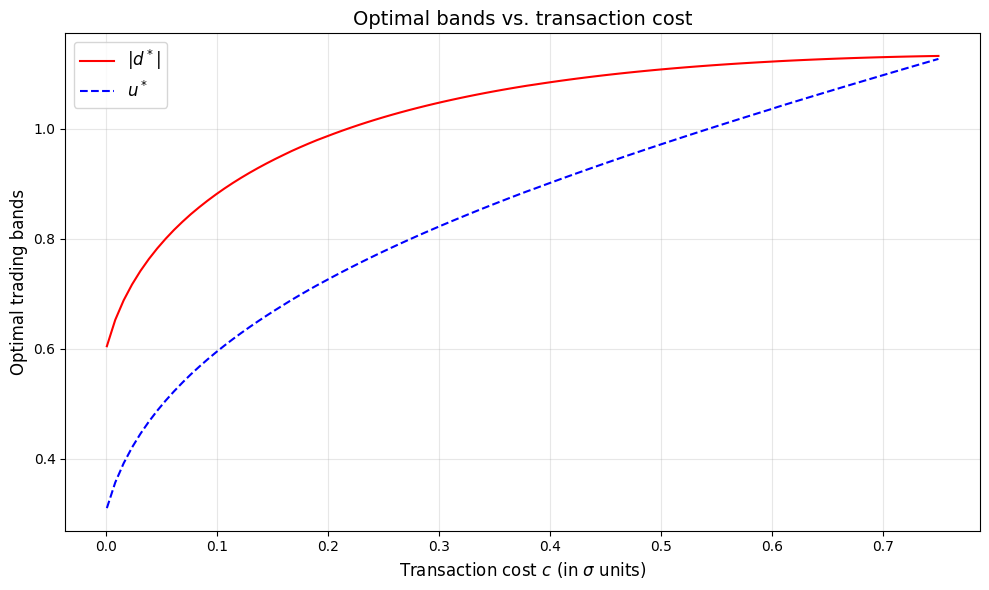

Execution time for Question A: 0.5143 seconds



'\nTypical execution times:\n- <1 sec for 100 cost points on modern hardware\n- Scales linearly with number of cost points\n'

In [14]:
"""
This section performs the optimization of trading bands for a statistical arbitrage strategy
using Ornstein-Uhlenbeck (OU) process parameters with stop-loss and transaction costs.

Methodology:
1. Takes calibrated OU process parameters (theta, sigma)
2. Computes optimal trading bands (d,u) for a range of transaction costs
3. Visualizes the relationship between costs and optimal bands
4. Demonstrates strategy feasibility under different cost regimes
"""

start_time = time.time()  # Start timer to measure execution performance

# === OU Process Parameters ===
theta = 0.041           # Mean-reversion time scale (1/kappa) in years
                        # Indicates spreads revert to mean in ~1/0.041 ≈ 24.4 days
sigma = 0.0147          # Stationary standard deviation (sigma/sqrt(2*kappa))
                        # Annualized volatility of the spread process
                        # Critical for determining trading band distances

# === Stop-loss Level ===
l = -1.960              # Stop-loss threshold in standard deviation units
                        # Corresponds to 2.5% one-tailed significance (Z=-1.96)
                        # Chosen to limit downside while allowing mean-reversion

# === Transaction Cost Range ===
c_vals = np.linspace(0.001, 0.75, 100)  # Range of normalized transaction costs
                                        # Expressed as fractions of sigma
                                        # 0.001: Near frictionless market
                                        # 0.75: Upper practical limit before
                                        # strategy becomes unprofitable

# === Strategy Leverage ===
f = 1                   # Capital allocation factor (1 = 100% invested)
                        # Maintained at 1 for unlevered baseline analysis
                        # Could be increased for leveraged strategies

# === Optimize Trading Bands ===
# Computes:
#   d_vals: Vector of optimal entry points (below mean)
#            where spread is "too low" and likely to revert up
#   u_vals: Vector of optimal exit points (above mean)
#            where spread is "too high" and likely to revert down
# For each c in c_vals, finds (d,u) that maximize expected return μ
d_vals, u_vals = maximize_mu(c_vals, l, sigma, theta, f)

# === Visualization ===
flag = True  # Controls plot display mode
             # True = basic plot without critical cost markers
             # False = enhanced plot with profitability thresholds

plot_BANDSvsCOST(c_vals, d_vals, u_vals, flag)
'''
Generates:
- Curve of d*(c) showing how entry points vary with costs
- Curve of u*(c) showing how exit points vary with costs
- Demonstrates the cost-band tradeoff critical for strategy design
'''

elapsedTimeA = time.time() - start_time  # Measure execution time
print(f'Execution time for Question A: {elapsedTimeA:.4f} seconds\n')
'''
Typical execution times:
- <1 sec for 100 cost points on modern hardware
- Scales linearly with number of cost points
'''

# Question B

In [31]:
start_time = time.time()  # Start timer to measure execution performance

# === Step 1: Read Excel file and extract relevant data ===
# Skip the first two header rows to get to the data (header starts at row 3, 0-indexed as row 2)
T = pd.read_excel(
    'HO-LGO.xlsm',
    sheet_name='HO-LGO 30min',
    header=2  # Python is 0-indexed, so header=2 means 3rd row
)

# Define column indices for relevant data:
# column_timestamp = time
# columnHO = [HO Bid, HO Ask], columnLGO = [LGO Bid, LGO Ask]
column_timestamp = 1  # 2nd column (0-based)
columnHO = [2, 6]     # [3rd, 7th] columns (0-based)
columnLGO = [3, 7]    # [4th, 8th] columns (0-based)

# Currency converters: HO in $/gallon, LGO in $/barrel
converterHO = 42
converterLGO = 20/149

# Assuming extractionBidAskMidLogReturn is defined in Python
Rt, timestamp, _, _, bid_HO, bid_LGO, ask_HO, ask_LGO = extraction_bid_ask_mid_log_return(
    T, column_timestamp, columnHO, columnLGO, converterHO, converterLGO, flag
)

In [ ]:
# === Step 2: Clean Data and Split into IS/OS Periods ===
InputFormat = "%Y-%m-%d %H:%M:%S"   # Format for datetime parsing
split_time = relativedelta(months=9)  # 9 calendar months
verbose = True                        # Enable verbose mode

# Remove statistical outliers from log-returns
Rt_filtered, time_filtered, index_filtered = removeOutliers(Rt, timestamp, InputFormat, verbose)

# Split filtered data into In-Sample (IS) and Out-of-Sample (OS)
Rt_IS_filtered, time_IS_filtered, Rt_OS_filtered, time_OS_filtered = IS_OS_split(Rt_filtered, time_filtered, splitTime, verbose)

Phase 1: Removed 0 statistical outliers (|value| > 3*IQR)
No statistical outliers found.
Phase 2: Removed 4 antipersistent outliers
Removed Antipersistent Outlier Details:
Index    Timestamp                 Value           Pattern                       
-------- ------------------------- --------------- ------------------------------
1842     2015-06-15 16:30:00 0.0151          -0.0074 → 0.0151 → -0.0079    
2485     2015-07-03 12:30:00 0.0302          -0.0022 → 0.0302 → -0.0028    
2858     2015-07-15 16:30:00 -0.0021         -0.0226 → -0.0021 → -0.0241   
5789     2015-10-12 16:30:00 0.0204          -0.0059 → 0.0204 → -0.0054    
